In [39]:
import pandas as pd

In [40]:
df_in = pd.read_csv("insurance.csv")

In [41]:
df_in

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Exploration

In [42]:
df_in.sex.value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [43]:
df_in.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [44]:
df_in.region.value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [45]:
df_in.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [46]:
df_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## preprocessing

In [47]:
df_in['sex'] = df_in["sex"].apply(lambda x: 1 if x == "Male" else 0)
df_in['smoker'] = df_in["smoker"].apply(lambda x: 1 if x == "yes" else 0)

In [48]:
df_in = df_in.join(pd.get_dummies(df_in.region, dtype=int)).drop('region', axis=1)

In [49]:
df_in

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'charges'}>],
       [<Axes: title={'center': 'northeast'}>,
        <Axes: title={'center': 'northwest'}>,
        <Axes: title={'center': 'southeast'}>],
       [<Axes: title={'center': 'southwest'}>, <Axes: >, <Axes: >]],
      dtype=object)

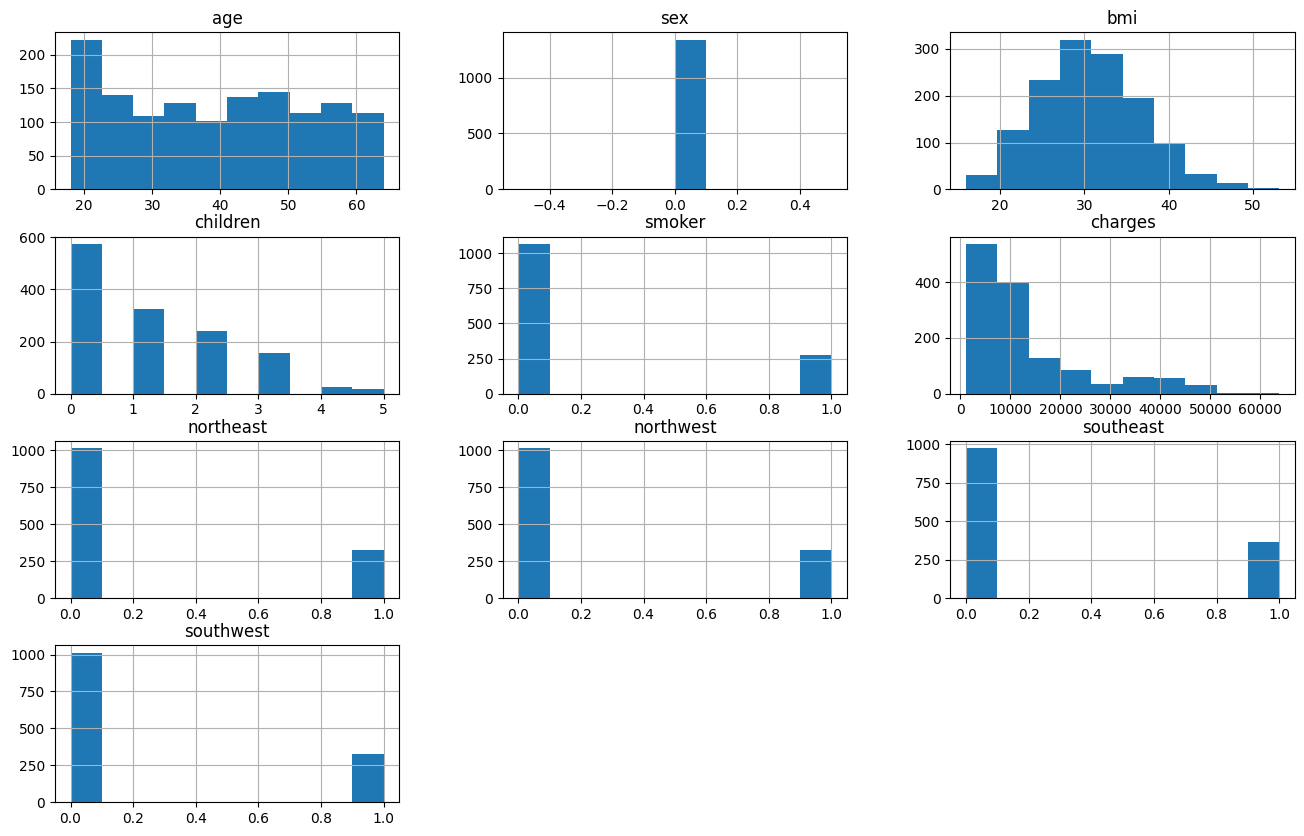

In [50]:
df_in.hist(figsize=(16,10))

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

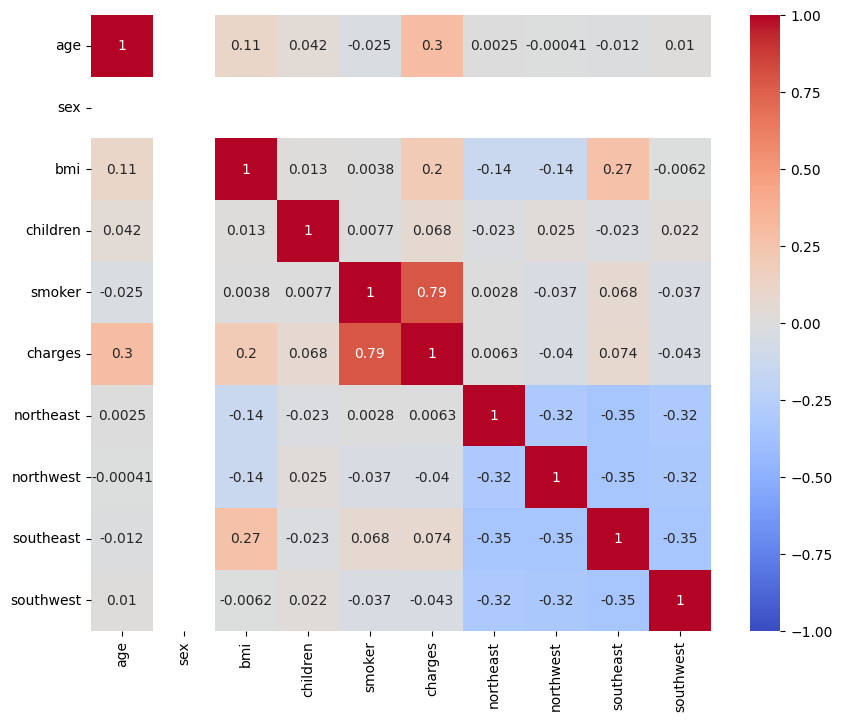

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_in.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [54]:
X = df_in.drop('charges', axis=1)
y = df_in.charges

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2)

In [55]:
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:
model.score(X_test, y_test)

0.793771225243501

In [57]:
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

In [58]:
rmse

5477.828194504435

In [59]:
import numpy as np

Text(0.5, 1.0, 'Prediction vs Truth')

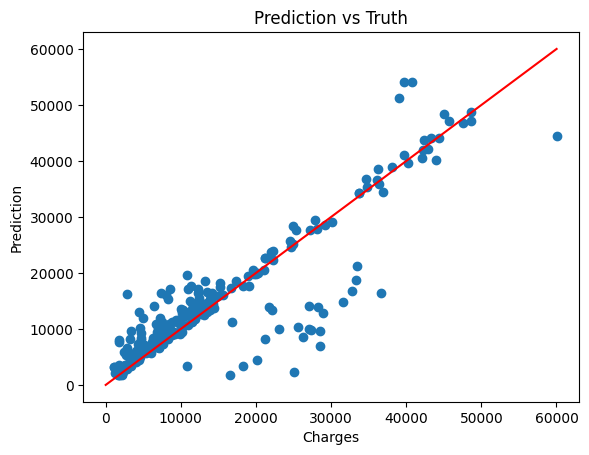

In [60]:
plt.scatter(y_test, y_pred)
plt.plot(np.linspace(0,max(y_test)), np.linspace(0, max(y_test)), color="red")
plt.xlabel('Charges')
plt.ylabel('Prediction')
plt.title("Prediction vs Truth")

Pretty decent prediction for most of the points, not for all of them 

## Hyperparameter Tuning

In [61]:
from sklearn.model_selection import GridSearchCV

In [62]:
param_grid = {
    'max_depth' : [None, 2, 5],
    'min_samples_split' : [2,4,6,8],
    'min_samples_leaf' : [1,2,4,6]
}

In [63]:
model = RandomForestRegressor(n_jobs=-1)

In [64]:
grid_search = GridSearchCV(model,param_grid, cv=5)

In [65]:
grid_search.fit(X_train, y_train)

,estimator,RandomForestR...sor(n_jobs=-1)
,param_grid,"{'max_depth': [None, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [66]:
grid_search.best_params_

{'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 4}

In [68]:
model = grid_search.best_estimator_


In [69]:
model

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
model.score(X_test,y_test)

0.8307838998183434

In [71]:
y_pred = model.predict(X_test)

In [72]:
rmse = root_mean_squared_error(y_test, y_pred)

In [73]:
rmse

4961.975518212864

### A little bit improvement